# Forward Model Pipeline

This notebook is the "hello world" of NEREIDS — the complete forward-modeling
pipeline from nuclear data to a simulated measurement, then closing the loop
by fitting the noisy result.

| Step | NEREIDS function |
|------|-----------------|
| 1. Load nuclear data | `load_endf()` |
| 2. Compute cross-sections | `cross_sections()` |
| 3. Apply Doppler broadening | `doppler_broaden()` |
| 4. Apply instrument resolution | `resolution_broaden()` |
| 5. Beer-Lambert transmission | `forward_model()` |
| 6. Add Poisson noise | NumPy |
| 7. Fit spectrum → recover densities | `from_transmission()` + `spatial_map_typed()` |

## Prerequisites

```bash
pixi run build
```

**Previous:** [Tabulated Resolution](../building_blocks/05_custom_resolution.ipynb)  
**Next:** [Spatial Mapping — Synthetic](04_spatial_mapping_synthetic.ipynb)

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 12

## 1. Load Nuclear Data

NEREIDS fetches and caches ENDF resonance parameters from the IAEA database.
The data contains resonance energies, widths, and quantum numbers used by the
Reich-Moore R-matrix formalism to compute cross-sections from evaluated nuclear
data — high-fidelity physics models fit to measurements, not first-principles
quantum-mechanical solutions.

In [2]:
# Load U-235 and Pu-241 from ENDF/B-VIII.1
u235  = nereids.load_endf(92, 235)
pu241 = nereids.load_endf(94, 241)

print(u235)
print(pu241)
print(f"U-235 scattering radius: {u235.scattering_radius:.3f} fm")
print(f"U-235 L-values: {u235.l_values}")

ResonanceData(Z=92, A=235, AWR=233.025, n_resonances=3194)
ResonanceData(Z=94, A=241, AWR=238.978, n_resonances=243)
U-235 scattering radius: 8.930 fm
U-235 L-values: [0]


## 2. Compute Cross-Sections

The resonance formalism (Reich-Moore for most isotopes) gives
energy-dependent cross-sections with characteristic resonance peaks.

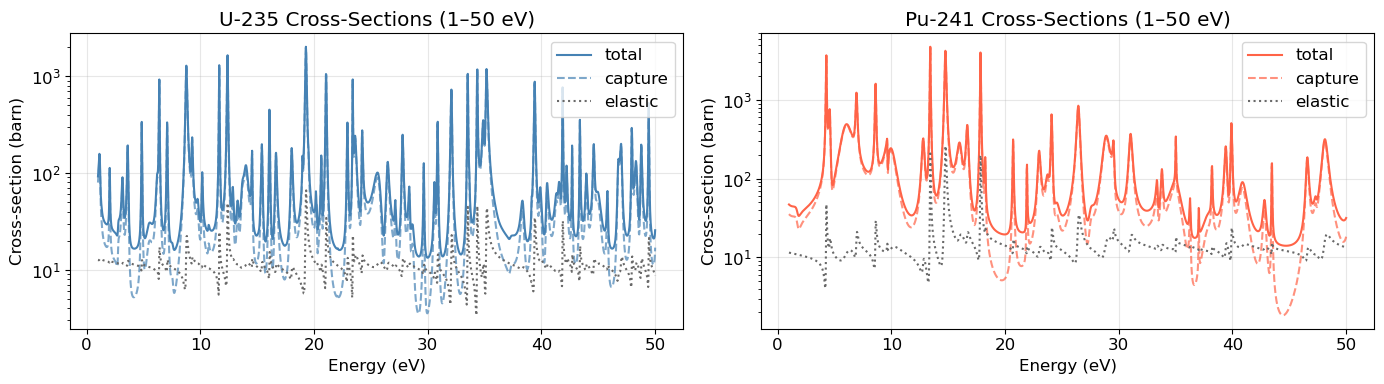

In [3]:
# Fine energy grid: 1–50 eV with 2000 points
# Dense enough to resolve individual resonance peaks
energies = np.linspace(1.0, 50.0, 2000)

xs_u235  = nereids.cross_sections(energies, u235)
xs_pu241 = nereids.cross_sections(energies, pu241)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, xs, name, color in [
    (axes[0], xs_u235,  'U-235',  'steelblue'),
    (axes[1], xs_pu241, 'Pu-241', 'tomato'),
]:
    ax.semilogy(energies, xs['total'],   color=color,     label='total')
    ax.semilogy(energies, xs['capture'], color=color,     label='capture', linestyle='--', alpha=0.7)
    ax.semilogy(energies, xs['elastic'], color='dimgray', label='elastic', linestyle=':')
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Cross-section (barn)')
    ax.set_title(f'{name} Cross-Sections (1–50 eV)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Doppler Broadening

At finite temperature, thermal motion of the target nuclei broadens resonances.
NEREIDS implements the Free Gas Model (FGM), identical to SAMMY's Doppler kernel.

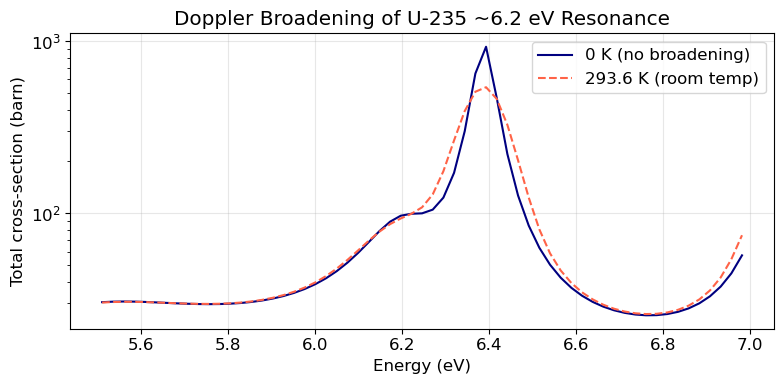

Peak reduction: 925 → 539 barn (41.8% lower)


In [4]:
# Compare 0 K (no broadening) vs 293.6 K (room temperature)
xs_cold = xs_u235['total']
xs_warm = nereids.doppler_broaden(energies, xs_cold, awr=u235.awr, temperature_k=293.6)

# Zoom in on a single resonance (~6.2 eV)
mask = (energies > 5.5) & (energies < 7.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(energies[mask], xs_cold[mask], label='0 K (no broadening)', color='navy')
ax.semilogy(energies[mask], xs_warm[mask], label='293.6 K (room temp)', color='tomato', linestyle='--')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Total cross-section (barn)')
ax.set_title('Doppler Broadening of U-235 ~6.2 eV Resonance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peak_cold = xs_cold[mask].max()
peak_warm = xs_warm[mask].max()
print(f"Peak reduction: {peak_cold:.0f} → {peak_warm:.0f} barn ({(1-peak_warm/peak_cold)*100:.1f}% lower)")

## 4. Instrument Resolution Broadening

The TOF spectrometer has finite energy resolution determined by the flight path
length and timing uncertainties. Resolution broadening smears the spectrum
further, especially at high energies where the TOF-to-energy Jacobian is steep.

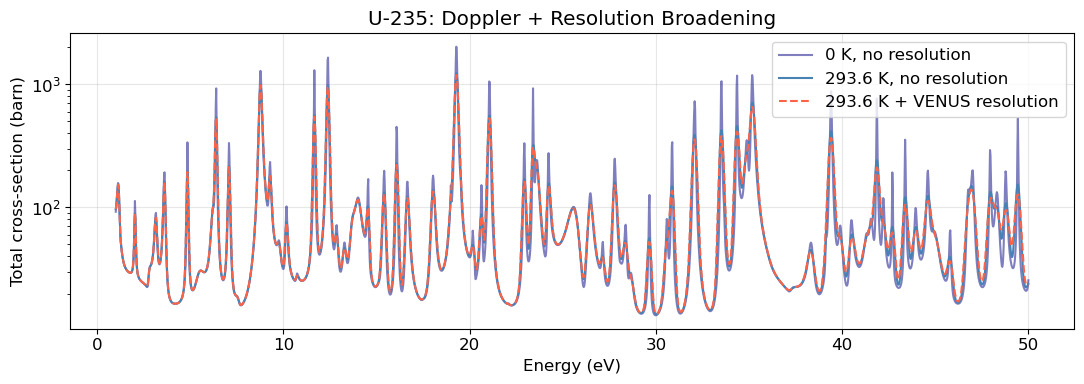

In [5]:
# VENUS beamline: 25 m flight path, ~0.3 μs timing uncertainty, ~0.01 m path uncertainty
flight_path_m = 25.0
delta_t_us    = 0.3
delta_l_m     = 0.01

xs_resolved = nereids.resolution_broaden(
    energies, xs_warm,
    flight_path_m=flight_path_m,
    delta_t_us=delta_t_us,
    delta_l_m=delta_l_m,
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(energies, xs_cold,     label='0 K, no resolution',       color='navy',    alpha=0.5)
ax.semilogy(energies, xs_warm,     label='293.6 K, no resolution',   color='steelblue')
ax.semilogy(energies, xs_resolved, label='293.6 K + VENUS resolution', color='tomato', linestyle='--')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Total cross-section (barn)')
ax.set_title('U-235: Doppler + Resolution Broadening')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Beer-Lambert Transmission

The neutron transmission through a sample is:

$$T(E) = \exp\!\left(-n_1 \sigma_1(E) - n_2 \sigma_2(E) - \cdots\right)$$

where $n_i$ (atoms/barn) is the areal density of isotope $i$.

`forward_model()` combines ENDF loading, Doppler broadening, resolution broadening,
and Beer-Lambert in a single call.

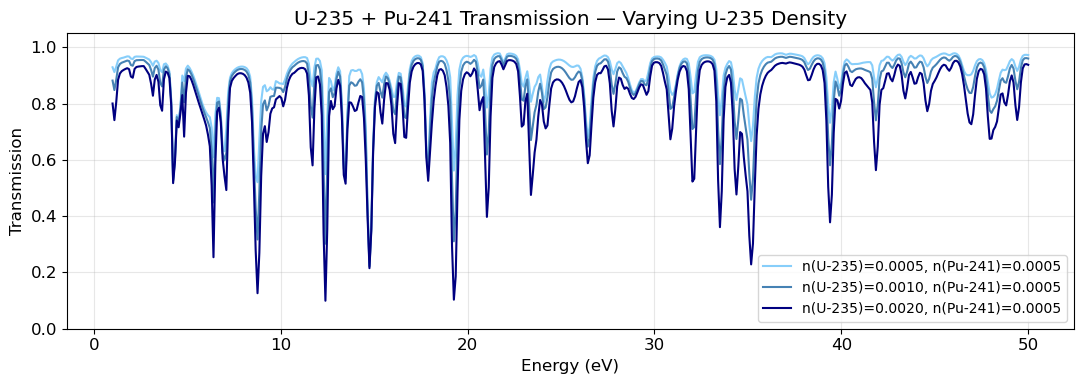

In [6]:
# Coarser grid matching the PLEIADES reference dataset
energies_500 = np.linspace(1.0, 50.0, 500)

# True densities (matches PLEIADES LANL-ORNL_example.tif ground truth)
TRUE_DENSITY_U235  = 0.001025  # atoms/barn
TRUE_DENSITY_PU241 = 0.0004998 # atoms/barn

# Vary U-235 density while holding Pu-241 fixed
densities = [0.0005, TRUE_DENSITY_U235, 0.002]
colors    = ['lightskyblue', 'steelblue', 'navy']

fig, ax = plt.subplots(figsize=(11, 4))
for dens, col in zip(densities, colors):
    t = nereids.forward_model(
        energies_500,
        [(u235, dens), (pu241, TRUE_DENSITY_PU241)],
        temperature_k=293.6,
    )
    ax.plot(energies_500, t, color=col,
            label=f'n(U-235)={dens:.4f}, n(Pu-241)={TRUE_DENSITY_PU241:.4f}')

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('U-235 + Pu-241 Transmission — Varying U-235 Density')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Simulate a Noisy Measurement

Real VENUS data has Poisson counting statistics. We simulate a measurement
by sampling from a Poisson distribution with mean = (open-beam counts) × T(E).

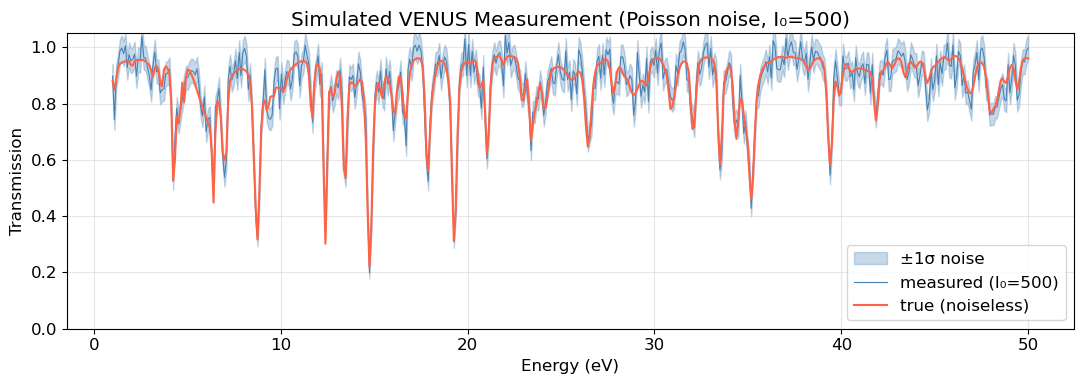

Mean relative uncertainty: 4.9%


In [7]:
# Clean theoretical spectrum at true densities
t_true = nereids.forward_model(
    energies_500,
    [(u235, TRUE_DENSITY_U235), (pu241, TRUE_DENSITY_PU241)],
    temperature_k=293.6,
)

# Simulate Poisson counts: I_0 = 500 neutrons/bin (typical VENUS low-count regime)
I0  = 500.0
rng = np.random.default_rng(0)
measured_counts = rng.poisson(I0 * t_true)
t_measured      = measured_counts / I0
# Poisson uncertainty: σ_T = √I / I0
sigma_t         = np.sqrt(np.maximum(measured_counts, 1.0)) / I0

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(energies_500, t_measured - sigma_t, t_measured + sigma_t,
                alpha=0.3, color='steelblue', label='±1σ noise')
ax.plot(energies_500, t_measured, color='steelblue', lw=0.8, label='measured (I₀=500)')
ax.plot(energies_500, t_true,     color='tomato',    lw=1.5, label='true (noiseless)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Simulated VENUS Measurement (Poisson noise, I₀=500)')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean relative uncertainty: {(sigma_t / np.clip(t_measured, 1e-6, None)).mean()*100:.1f}%")

## 7. Closed-Loop Validation: Fit → Recover True Densities

We fit the noisy spectrum using `spatial_map_typed()` on a 1x1 pixel
"image" to test closed-loop recovery. The typed API replaces the old
`fit_roi()` function — slice your data manually, then wrap with
`from_transmission()` or `from_counts()`.

In [ ]:
# Wrap the 1D spectrum as a 3D (n_e, 1, 1) array for spatial_map_typed
trans_3d = np.ascontiguousarray(t_measured.reshape(-1, 1, 1))
sigma_3d = np.ascontiguousarray(sigma_t.reshape(-1, 1, 1))

data = nereids.from_transmission(trans_3d, sigma_3d)
result = nereids.spatial_map_typed(
    data, energies_500,
    [u235, pu241],
    temperature_k=293.6,
    initial_densities=[0.001, 0.001],
)

# Extract single-pixel results
converged = bool(np.array(result.converged_map)[0, 0])
chi2_red = float(np.array(result.chi_squared_map)[0, 0])
fit_densities = [float(m[0, 0]) for m in result.density_maps]
fit_uncertainties = [float(m[0, 0]) for m in result.uncertainty_maps]

print(f"Fit converged: {converged}")
print(f"Reduced chi-squared: {chi2_red:.3f}")
print()
print(f"{'Isotope':<10} {'True':>12} {'Fitted':>12} {'Uncertainty':>13} {'Error':>8}")
print("-" * 60)
names  = ['U-235', 'Pu-241']
truths = [TRUE_DENSITY_U235, TRUE_DENSITY_PU241]
for name, truth, fitted, unc in zip(names, truths, fit_densities, fit_uncertainties):
    err_pct = (fitted - truth) / truth * 100
    print(f"{name:<10} {truth:>12.6f} {fitted:>12.6f} {unc:>13.6f} {err_pct:>7.2f}%")

In [ ]:
# Overlay the fitted model on the noisy measurement
t_fitted = nereids.forward_model(
    energies_500,
    [(u235, fit_densities[0]), (pu241, fit_densities[1])],
    temperature_k=293.6,
)

residuals = (t_measured - t_fitted) / sigma_t

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

ax1.fill_between(energies_500, t_measured - sigma_t, t_measured + sigma_t,
                 alpha=0.3, color='steelblue')
ax1.plot(energies_500, t_measured, color='steelblue', lw=0.8, label='measured')
ax1.plot(energies_500, t_true,     color='tomato',    lw=1.5, label='true (noiseless)', zorder=3)
ax1.plot(energies_500, t_fitted,   color='black',     lw=1.5, label='fitted', linestyle='--', zorder=4)
ax1.set_ylabel('Transmission')
ax1.legend()
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
ax1.set_title('Closed-Loop Validation: Fitted Model vs Measurement')

ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(+1, color='gray', lw=0.5, linestyle='--')
ax2.axhline(-1, color='gray', lw=0.5, linestyle='--')
ax2.plot(energies_500, residuals, color='steelblue', lw=0.7)
ax2.set_xlabel('Energy (eV)')
ax2.set_ylabel('Residual (σ)')
ax2.set_ylim(-4, 4)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Sensitivity: How Transmission Responds to Density Changes

Each isotope's signature is uniquely encoded in the spectrum by its
resonance pattern. Isotopes with more or stronger resonances in the
energy window are easier to discriminate.

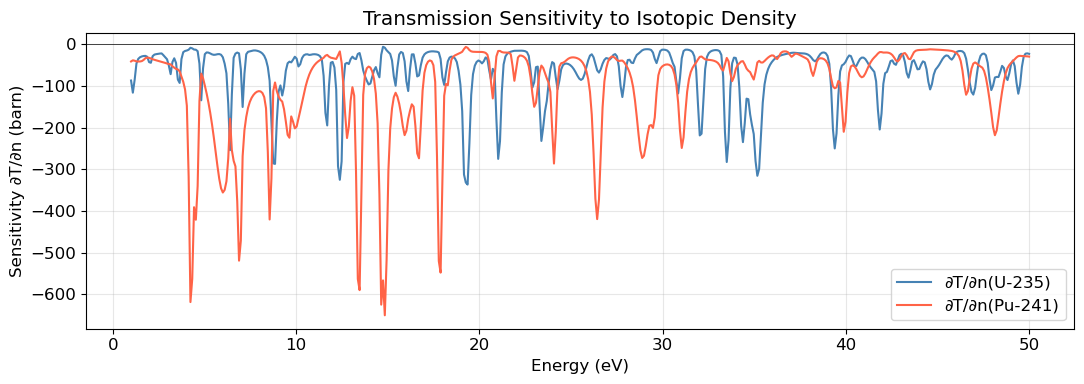

Orthogonality check (dot product of sensitivity vectors, normalized):
  cos θ = 0.403  (0 = orthogonal, ideal for fitting)


In [10]:
delta = 0.0001  # small perturbation
t_u235_plus  = nereids.forward_model(energies_500,
    [(u235, TRUE_DENSITY_U235 + delta), (pu241, TRUE_DENSITY_PU241)], temperature_k=293.6)
t_pu241_plus = nereids.forward_model(energies_500,
    [(u235, TRUE_DENSITY_U235), (pu241, TRUE_DENSITY_PU241 + delta)], temperature_k=293.6)

sens_u235  = (t_u235_plus  - t_true) / delta
sens_pu241 = (t_pu241_plus - t_true) / delta

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(energies_500, sens_u235,  label='∂T/∂n(U-235)',  color='steelblue')
ax.plot(energies_500, sens_pu241, label='∂T/∂n(Pu-241)', color='tomato')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Sensitivity ∂T/∂n (barn)')
ax.set_title('Transmission Sensitivity to Isotopic Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Orthogonality check (dot product of sensitivity vectors, normalized):")
norm = np.linalg.norm(sens_u235) * np.linalg.norm(sens_pu241)
print(f"  cos θ = {np.dot(sens_u235, sens_pu241) / norm:.3f}  (0 = orthogonal, ideal for fitting)")

## Summary

This notebook demonstrated the complete NEREIDS forward-modeling pipeline:

1. **Cross-sections** via Reich-Moore R-matrix formalism on evaluated ENDF resonance data
2. **Doppler broadening** via Free Gas Model — thermal motion widens peaks
3. **Resolution broadening** — instrument smearing encoded as Gaussian in TOF
4. **Beer-Lambert transmission** — each isotope attenuates the beam by its own resonance pattern
5. **Poisson noise** — simulates finite counting statistics at VENUS
6. **Closed-loop fit** — `spatial_map_typed()` on a 1x1 pixel recovers true densities; errors are typically a few percent for a single noisy pixel at I₀ = 500 (Poisson-noise-limited, not a systematic bias)

> **Note on single-pixel fit accuracy:** With one noisy spectrum at I₀ = 500, per-realisation
> errors of ±3–6 % are expected from Poisson fluctuations alone. Averaging over multiple pixels
> (e.g. via `spatial_map_typed()` + zone averaging) reduces this to well below 1 %.

### Typical Workflow for Real Data

```python
import nereids, numpy as np

# 1. Load nuclear data
u235  = nereids.load_endf(92, 235)
pu241 = nereids.load_endf(94, 241)

# 2. Compute forward model at any density
t_model = nereids.forward_model(energies, [(u235, 0.001), (pu241, 0.0005)],
                                 temperature_k=293.6)

# 3. Fit a measured spectrum (wrap as 3D for the typed API)
data = nereids.from_transmission(trans_3d, uncertainty_3d)
result = nereids.spatial_map_typed(data, energies, [u235, pu241])
print(result.density_maps)  # list of 2D arrays, one per isotope
```

**Next:** [Spatial Mapping — Synthetic](04_spatial_mapping_synthetic.ipynb) — full
per-pixel isotopic mapping on a programmatically generated 3D transmission cube.